# Materials Cost-Effectiveness Analysis

This notebook combines the clustered materials outputs with the price proxies from the matching stage. The aim is to classify cost within technically similar groups, not across the entire material universe, and then highlight lower-cost candidate alternatives among materials that are close enough to be compared meaningfully.

In [28]:
# Import the libraries used in this notebook section.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

In [29]:
# Set up project paths so files can be read and outputs can be organised consistently.
cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name == "notebooks" else cwd

pricing_results_dir = project_root / "results" / "materials_pricing"
results_dir = pricing_results_dir
supporting_results_dir = results_dir / "supporting"
supporting_results_dir.mkdir(parents=True, exist_ok=True)

matched_materials_path = results_dir / "materials_with_price_matches.csv"
# Group similar records and evaluate the quality of the cluster structure.
cluster_neighbors_path = project_root / "results" / "materials_clustering" / "materials_cluster_nearest_neighbors.csv"

cluster_cost_classes_output = results_dir / "materials_cluster_cost_classes.csv"
cost_effective_alternatives_output = results_dir / "cost_effective_alternatives.csv"
cluster_cost_summary_output = supporting_results_dir / "cluster_cost_summary.csv"

print("Matched materials file:", matched_materials_path)
print("Cluster neighbors file:", cluster_neighbors_path)
print("Results directory:", results_dir)

Matched materials file: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\materials_pricing\materials_with_price_matches.csv
Cluster neighbors file: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\materials_clustering\materials_cluster_nearest_neighbors.csv
Results directory: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\materials_pricing


In [30]:
# Check that the expected input files are available before continuing.
for path in [matched_materials_path, cluster_neighbors_path]:
    if not path.exists():
        # Handle missing values so later transformations and models do not fail.
        raise FileNotFoundError(f"Missing required input file: {path}")

## Load matched pricing data and cluster-neighbor relationships

In [31]:
# Load the dataset needed for the next analysis step.
matched_materials_df = pd.read_csv(matched_materials_path)
# Group similar records and evaluate the quality of the cluster structure.
cluster_neighbors_df = pd.read_csv(cluster_neighbors_path)

# Inspect the data to confirm the structure and values look reasonable.
print("Matched materials shape:", matched_materials_df.shape)
display(matched_materials_df.head())

print("Cluster neighbors shape:", cluster_neighbors_df.shape)
display(cluster_neighbors_df.head())

Matched materials shape: (33951, 24)


,material_id,formula_pretty,formula_match_key,elements,elements_list,material_family_key,material_family_match_key,is_stable,is_metal,symmetry,cluster_label,elements_parsed,formula_elements_ordered,primary_element_symbol,primary_element_name,single_element_name,candidate_price_keys,price_match_key,price_material,cost,unit,year,match_type,match_confidence
0,mp-862690,Ac,ac,['Ac'],['Ac'],Ac,ac,True,True,Hexagonal,3,['Ac'],['Ac'],Ac,NaN,NaN,[],NaN,NaN,NaN,NaN,NaN,unmatched,none
1,mp-1183076,Ac2AgPb,ac2agpb,"['Ac', 'Ag', 'Pb']","['Ac', 'Ag', 'Pb']",Ac_Ag_Pb,ac_ag_pb,True,True,Cubic,3,"['Ac', 'Ag', 'Pb']","['Ac', 'Ag', 'Pb']",Ac,NaN,NaN,"['silver', 'lead']",silver,Silver,39.804667,($/troy oz),2025.0,family_level_proxy,low
2,mp-1183086,Ac2CdHg,ac2cdhg,"['Ac', 'Cd', 'Hg']","['Ac', 'Cd', 'Hg']",Ac_Cd_Hg,ac_cd_hg,True,True,Cubic,3,"['Ac', 'Cd', 'Hg']","['Ac', 'Cd', 'Hg']",Ac,NaN,NaN,[],NaN,NaN,NaN,NaN,NaN,unmatched,none
3,mp-862786,Ac2CuGe,ac2cuge,"['Ac', 'Cu', 'Ge']","['Ac', 'Cu', 'Ge']",Ac_Cu_Ge,ac_cu_ge,True,True,Cubic,3,"['Ac', 'Cu', 'Ge']","['Ac', 'Cu', 'Ge']",Ac,NaN,NaN,['copper'],copper,Copper,9947.305000,($/mt),2025.0,family_level_proxy,low
4,mp-861883,Ac2CuIr,ac2cuir,"['Ac', 'Cu', 'Ir']","['Ac', 'Cu', 'Ir']",Ac_Cu_Ir,ac_cu_ir,True,True,Cubic,3,"['Ac', 'Cu', 'Ir']","['Ac', 'Cu', 'Ir']",Ac,NaN,NaN,['copper'],copper,Copper,9947.305000,($/mt),2025.0,family_level_proxy,low


Cluster neighbors shape: (169755, 8)


,cluster_label,source_row_index,source_material_id,source_formula_pretty,neighbor_row_index,neighbor_material_id,neighbor_formula_pretty,similarity_distance
0,0,80,mp-567334,Ag(BCl)6,16167,mp-532413,Li5B7S13,0.900152
1,0,80,mp-567334,Ag(BCl)6,19679,mp-640950,NaB9Se8,1.085639
2,0,80,mp-567334,Ag(BCl)6,19542,mp-1220895,Na6B18Se17,1.113587
3,0,80,mp-567334,Ag(BCl)6,12969,mp-572510,K3AgO2,1.213461
4,0,80,mp-567334,Ag(BCl)6,20817,mp-1199401,Nd(NO3)3,1.300213


## Keep the reliable pricing subset

The downstream cost analysis should only use materials with usable price proxies. This keeps the comparison honest and avoids making claims from weak or missing price coverage.

In [32]:
# Filter the data to keep the records relevant for this step.
usable_confidence_levels = ["high", "medium"]
priced_materials_df = matched_materials_df[
    matched_materials_df["match_confidence"].isin(usable_confidence_levels)
    # Handle missing values so later transformations and models do not fail.
    & matched_materials_df["cost"].notna()
].copy()

# Inspect the data to confirm the structure and values look reasonable.
print("Priced materials shape:", priced_materials_df.shape)
display(
    priced_materials_df[[
        # Group similar records and evaluate the quality of the cluster structure.
        "material_id", "formula_pretty", "cluster_label", "price_material", "cost", "unit", "year", "match_type", "match_confidence"
    ]].head(20)
)

Priced materials shape: (1462, 24)


,material_id,formula_pretty,cluster_label,price_material,cost,unit,year,match_type,match_confidence
78,mp-8566,Ag,3,Silver,39.804667,($/troy oz),2025.0,single_element_proxy,high
79,mp-18125,Ag(AuF4)2,4,Silver,39.804667,($/troy oz),2025.0,primary_element_proxy,medium
80,mp-567334,Ag(BCl)6,0,Silver,39.804667,($/troy oz),2025.0,primary_element_proxy,medium
81,mp-29607,Ag(TeMo)6,3,Silver,39.804667,($/troy oz),2025.0,primary_element_proxy,medium
82,mp-568392,Ag10Te4Br3,0,Silver,39.804667,($/troy oz),2025.0,primary_element_proxy,medium
83,mp-1195193,Ag12Sn7H16(Se11N2)2,0,Silver,39.804667,($/troy oz),2025.0,primary_element_proxy,medium
84,mp-560328,Ag15P4S16Cl3,0,Silver,39.804667,($/troy oz),2025.0,primary_element_proxy,medium
85,mp-554873,Ag2B8O13,2,Silver,39.804667,($/troy oz),2025.0,primary_element_proxy,medium
86,mp-23558,Ag2BiO3,4,Silver,39.804667,($/troy oz),2025.0,primary_element_proxy,medium
87,mp-862982,Ag2Br3,4,Silver,39.804667,($/troy oz),2025.0,primary_element_proxy,medium


## Assign cost classes within cluster

Cost classes are created inside each cluster so a material is judged relative to technically similar materials, not against the whole dataset.

In [33]:
# Group similar records and evaluate the quality of the cluster structure.
def assign_within_cluster_cost_class(cluster_df, cluster_label):
    # Summarise the data so patterns can be compared more easily.
    cluster_df = cluster_df.sort_values("cost").copy()
    cluster_df["cluster_label"] = cluster_label
    # Filter the data to keep the records relevant for this step.
    unique_cost_count = cluster_df["cost"].nunique(dropna=True)

    if len(cluster_df) < 3 or unique_cost_count < 3:
        cluster_df["cost_class_within_cluster"] = "insufficient_cluster_cost_variety"
        cluster_df["cost_rank_within_cluster"] = range(1, len(cluster_df) + 1)
        cluster_df["cluster_cost_percentile"] = np.nan
        return cluster_df

    cluster_df["cluster_cost_percentile"] = cluster_df["cost"].rank(method="average", pct=True)
    # Convert values into analysis-friendly numeric, date, or text formats.
    cluster_df["cost_rank_within_cluster"] = cluster_df["cost"].rank(method="dense", ascending=True).astype(int)
    cluster_df["cost_class_within_cluster"] = pd.qcut(
        cluster_df["cost"],
        q=3,
        labels=["low_cost", "medium_cost", "high_cost"],
        duplicates="drop",
    ).astype(str)
    return cluster_df

cluster_cost_class_frames = []
for cluster_label, cluster_subset_df in priced_materials_df.groupby("cluster_label"):
    cluster_cost_class_frames.append(assign_within_cluster_cost_class(cluster_subset_df, cluster_label))

# Combine related tables so each record has the fields needed for analysis.
cluster_cost_classes_df = pd.concat(cluster_cost_class_frames, ignore_index=True)

# Inspect the data to confirm the structure and values look reasonable.
display(cluster_cost_classes_df.head(20))

,material_id,formula_pretty,formula_match_key,elements,elements_list,material_family_key,material_family_match_key,is_stable,is_metal,symmetry,cluster_label,elements_parsed,formula_elements_ordered,primary_element_symbol,primary_element_name,single_element_name,candidate_price_keys,price_match_key,price_material,cost,unit,year,match_type,match_confidence,cluster_cost_percentile,cost_rank_within_cluster,cost_class_within_cluster
0,mp-567334,Ag(BCl)6,ag_bcl_6,"['Ag', 'B', 'Cl']","['Ag', 'B', 'Cl']",Ag_B_Cl,ag_b_cl,True,False,Cubic,0,"['Ag', 'B', 'Cl']","['Ag', 'B', 'Cl']",Ag,silver,NaN,['silver'],silver,Silver,39.804667,($/troy oz),2025.0,primary_element_proxy,medium,0.058594,1,low_cost
1,mp-568392,Ag10Te4Br3,ag10te4br3,"['Ag', 'Br', 'Te']","['Ag', 'Br', 'Te']",Ag_Br_Te,ag_br_te,True,False,Orthorhombic,0,"['Ag', 'Br', 'Te']","['Ag', 'Te', 'Br']",Ag,silver,NaN,['silver'],silver,Silver,39.804667,($/troy oz),2025.0,primary_element_proxy,medium,0.058594,1,low_cost
2,mp-1195193,Ag12Sn7H16(Se11N2)2,ag12sn7h16_se11n2_2,"['Ag', 'H', 'N', 'Se', 'Sn']","['Ag', 'H', 'N', 'Se', 'Sn']",Ag_H_N_Se_Sn,ag_h_n_se_sn,True,False,Monoclinic,0,"['Ag', 'H', 'N', 'Se', 'Sn']","['Ag', 'Sn', 'H', 'Se', 'N']",Ag,silver,NaN,"['silver', 'tin']",silver,Silver,39.804667,($/troy oz),2025.0,primary_element_proxy,medium,0.058594,1,low_cost
3,mp-560328,Ag15P4S16Cl3,ag15p4s16cl3,"['Ag', 'Cl', 'P', 'S']","['Ag', 'Cl', 'P', 'S']",Ag_Cl_P_S,ag_cl_p_s,True,False,Cubic,0,"['Ag', 'Cl', 'P', 'S']","['Ag', 'P', 'S', 'Cl']",Ag,silver,NaN,"['silver', 'phosphate_rock']",silver,Silver,39.804667,($/troy oz),2025.0,primary_element_proxy,medium,0.058594,1,low_cost
4,mp-1196546,Ag2Ge(S2O7)3,ag2ge_s2o7_3,"['Ag', 'Ge', 'O', 'S']","['Ag', 'Ge', 'O', 'S']",Ag_Ge_O_S,ag_ge_o_s,True,False,Trigonal,0,"['Ag', 'Ge', 'O', 'S']","['Ag', 'Ge', 'S', 'O']",Ag,silver,NaN,['silver'],silver,Silver,39.804667,($/troy oz),2025.0,primary_element_proxy,medium,0.058594,1,low_cost
5,mp-860963,Ag2H4(SO4)3,ag2h4_so4_3,"['Ag', 'H', 'O', 'S']","['Ag', 'H', 'O', 'S']",Ag_H_O_S,ag_h_o_s,True,False,Orthorhombic,0,"['Ag', 'H', 'O', 'S']","['Ag', 'H', 'S', 'O']",Ag,silver,NaN,['silver'],silver,Silver,39.804667,($/troy oz),2025.0,primary_element_proxy,medium,0.058594,1,low_cost
6,mp-1197599,Ag2Sn(S2O7)3,ag2sn_s2o7_3,"['Ag', 'O', 'S', 'Sn']","['Ag', 'O', 'S', 'Sn']",Ag_O_S_Sn,ag_o_s_sn,True,False,Trigonal,0,"['Ag', 'O', 'S', 'Sn']","['Ag', 'Sn', 'S', 'O']",Ag,silver,NaN,"['silver', 'tin']",silver,Silver,39.804667,($/troy oz),2025.0,primary_element_proxy,medium,0.058594,1,low_cost
7,mp-662599,Ag3AsSe3,ag3asse3,"['Ag', 'As', 'Se']","['Ag', 'As', 'Se']",Ag_As_Se,ag_as_se,True,False,Orthorhombic,0,"['Ag', 'As', 'Se']","['Ag', 'As', 'Se']",Ag,silver,NaN,['silver'],silver,Silver,39.804667,($/troy oz),2025.0,primary_element_proxy,medium,0.058594,1,low_cost
8,mp-1201018,Ag3S4(O3F)4,ag3s4_o3f_4,"['Ag', 'F', 'O', 'S']","['Ag', 'F', 'O', 'S']",Ag_F_O_S,ag_f_o_s,True,True,Monoclinic,0,"['Ag', 'F', 'O', 'S']","['Ag', 'S', 'O', 'F']",Ag,silver,NaN,['silver'],silver,Silver,39.804667,($/troy oz),2025.0,primary_element_proxy,medium,0.058594,1,low_cost
9,mp-558550,Ag4Mo2Se3O16,ag4mo2se3o16,"['Ag', 'Mo', 'O', 'Se']","['Ag', 'Mo', 'O', 'Se']",Ag_Mo_O_Se,ag_mo_o_se,True,False,Orthorhombic,0,"['Ag', 'Mo', 'O', 'Se']","['Ag', 'Mo', 'Se', 'O']",Ag,silver,NaN,['silver'],silver,Silver,39.804667,($/troy oz),2025.0,primary_element_proxy,medium,0.058594,1,low_cost


## Define similarity level from within-cluster proximity

In [34]:
# Filter the data to keep the records relevant for this step.
cluster_neighbors_df = cluster_neighbors_df.sort_values(["cluster_label", "source_material_id", "similarity_distance"]).copy()
# Summarise the data so patterns can be compared more easily.
cluster_neighbors_df["similarity_rank_within_source"] = cluster_neighbors_df.groupby(
    # Group similar records and evaluate the quality of the cluster structure.
    ["cluster_label", "source_material_id"]
)["similarity_distance"].rank(method="first", ascending=True).astype(int)
cluster_neighbors_df["similarity_distance_percentile"] = cluster_neighbors_df.groupby(
    ["cluster_label", "source_material_id"]
)["similarity_distance"].rank(method="average", pct=True)

def similarity_label_from_percentile(value):
    # Handle missing values so later transformations and models do not fail.
    if pd.isna(value):
        return "unknown"
    if value <= 0.33:
        return "high_similarity"
    if value <= 0.66:
        return "moderate_similarity"
    return "low_similarity"

cluster_neighbors_df["similarity_level"] = cluster_neighbors_df["similarity_distance_percentile"].apply(similarity_label_from_percentile)

# Inspect the data to confirm the structure and values look reasonable.
display(cluster_neighbors_df.head(20))

,cluster_label,source_row_index,source_material_id,source_formula_pretty,neighbor_row_index,neighbor_material_id,neighbor_formula_pretty,similarity_distance,similarity_rank_within_source,similarity_distance_percentile,similarity_level
1205,0,3096,mp-1004532,CCl4,21997,mp-652364,PNCl2,1.616682,1,0.2,high_similarity
1206,0,3096,mp-1004532,CCl4,19093,mp-30233,Na3As7,1.920814,2,0.4,moderate_similarity
1207,0,3096,mp-1004532,CCl4,25237,mp-572597,SbPS4,2.020452,3,0.6,moderate_similarity
1208,0,3096,mp-1004532,CCl4,14276,mp-1217,KSi,2.060022,4,0.8,low_similarity
1209,0,3096,mp-1004532,CCl4,13298,mp-556627,K4GeS4,2.086621,5,1.0,low_similarity
7930,0,23423,mp-1006574,Rb(Zr3Te4)4,14847,mp-29994,La3C2Br3,0.602846,1,0.2,high_similarity
7931,0,23423,mp-1006574,Rb(Zr3Te4)4,4654,mp-1215059,Ce3C2Br3,0.736203,2,0.4,moderate_similarity
7932,0,23423,mp-1006574,Rb(Zr3Te4)4,25307,mp-1200815,Sc13Os3Br16,0.842824,3,0.6,moderate_similarity
7933,0,23423,mp-1006574,Rb(Zr3Te4)4,9230,mp-684111,Eu3Sb4S9,0.848039,4,0.8,low_similarity
7934,0,23423,mp-1006574,Rb(Zr3Te4)4,5552,mp-1228320,Cs19(W2N5)6,1.020991,5,1.0,low_similarity


## Generate cost-effective alternatives inside technically similar groups

In [35]:
# Group similar records and evaluate the quality of the cluster structure.
source_cost_df = cluster_cost_classes_df[[
    "material_id", "formula_pretty", "cluster_label", "cost", "unit", "year", "cost_class_within_cluster", "cost_rank_within_cluster"
]].rename(columns={
    "material_id": "source_material_id",
    "formula_pretty": "source_formula_pretty",
    "cost": "source_cost",
    "unit": "source_unit",
    "year": "source_year",
    "cost_class_within_cluster": "source_cost_class",
    "cost_rank_within_cluster": "source_cost_rank_within_cluster",
})

neighbor_cost_df = cluster_cost_classes_df[[
    "material_id", "formula_pretty", "cluster_label", "cost", "unit", "year", "cost_class_within_cluster", "cost_rank_within_cluster"
]].rename(columns={
    "material_id": "neighbor_material_id",
    "formula_pretty": "neighbor_formula_pretty_verified",
    "cost": "neighbor_cost",
    "unit": "neighbor_unit",
    "year": "neighbor_year",
    "cost_class_within_cluster": "neighbor_cost_class",
    "cost_rank_within_cluster": "neighbor_cost_rank_within_cluster",
})

alternatives_df = (
    cluster_neighbors_df
    .merge(source_cost_df, on=["source_material_id", "cluster_label"], how="inner")
    .merge(neighbor_cost_df, on=["neighbor_material_id", "cluster_label"], how="inner")
)

# Filter the data to keep the records relevant for this step.
alternatives_df["cost_difference"] = alternatives_df["neighbor_cost"] - alternatives_df["source_cost"]
alternatives_df["cost_saving"] = alternatives_df["source_cost"] - alternatives_df["neighbor_cost"]
alternatives_df["is_lower_cost_alternative"] = alternatives_df["neighbor_cost"] < alternatives_df["source_cost"]

cost_effective_alternatives_df = alternatives_df[
    alternatives_df["is_lower_cost_alternative"]
    & alternatives_df["similarity_level"].isin(["high_similarity", "moderate_similarity"])
].copy()

# Summarise the data so patterns can be compared more easily.
cost_effective_alternatives_df = cost_effective_alternatives_df.sort_values(
    ["source_material_id", "similarity_level", "cost_saving"],
    ascending=[True, True, False]
).reset_index(drop=True)

# Inspect the data to confirm the structure and values look reasonable.
display(cost_effective_alternatives_df.head(20))

,cluster_label,source_row_index,source_material_id,source_formula_pretty_x,neighbor_row_index,neighbor_material_id,neighbor_formula_pretty,similarity_distance,similarity_rank_within_source,similarity_distance_percentile,similarity_level,source_formula_pretty_y,source_cost,source_unit,source_year,source_cost_class,source_cost_rank_within_cluster,neighbor_formula_pretty_verified,neighbor_cost,neighbor_unit,neighbor_year,neighbor_cost_class,neighbor_cost_rank_within_cluster,cost_difference,cost_saving,is_lower_cost_alternative
0,4,7502,mp-1018029,CuPd,33310,mp-6938,ZnRh,0.306505,1,0.2,high_similarity,CuPd,9947.305000,($/mt),2025.0,medium_cost,8,ZnRh,2867.528333,($/mt),2025.0,medium_cost,6,-7079.776667,7079.776667,True
1,1,22128,mp-1025039,PbS2,187,mp-23231,AgBr,0.489930,1,0.2,high_similarity,PbS2,1962.235000,($/mt),2025.0,low_cost,4,AgBr,39.804667,($/troy oz),2025.0,low_cost,1,-1922.430333,1922.430333,True
2,4,33091,mp-1047156,Zn(CuO2)2,88,mp-4691,Ag2CO3,0.303195,2,0.4,moderate_similarity,Zn(CuO2)2,2867.528333,($/mt),2025.0,medium_cost,6,Ag2CO3,39.804667,($/troy oz),2025.0,low_cost,1,-2827.723667,2827.723667,True
3,3,21592,mp-1070761,Ni(BW)2,33088,mp-28786,Zn(BIr)2,0.219849,2,0.4,moderate_similarity,Ni(BW)2,15162.158333,($/mt),2025.0,high_cost,9,Zn(BIr)2,2867.528333,($/mt),2025.0,medium_cost,6,-12294.630000,12294.630000,True
4,4,21675,mp-1078540,Ni6Ge2B,500,mp-1228832,AlNi6Ge,0.128342,3,0.6,moderate_similarity,Ni6Ge2B,15162.158333,($/mt),2025.0,high_cost,9,AlNi6Ge,2631.695833,($/mt),2025.0,low_cost,5,-12530.462500,12530.462500,True
5,3,521,mp-10909,AlRe2,21995,mp-2082,PIr2,0.256811,1,0.2,high_similarity,AlRe2,2631.695833,($/mt),2025.0,low_cost,5,PIr2,152.500000,($/mt),2025.0,low_cost,2,-2479.195833,2479.195833,True
6,4,324,mp-10910,Al2Ru,21913,mp-1413,P2Ru,0.317452,1,0.2,high_similarity,Al2Ru,2631.695833,($/mt),2025.0,low_cost,5,P2Ru,152.500000,($/mt),2025.0,low_cost,2,-2479.195833,2479.195833,True
7,4,324,mp-10910,Al2Ru,21911,mp-15953,P2Rh,0.406485,2,0.4,moderate_similarity,Al2Ru,2631.695833,($/mt),2025.0,low_cost,5,P2Rh,152.500000,($/mt),2025.0,low_cost,2,-2479.195833,2479.195833,True
8,2,21587,mp-1096784,Ni(AsO2)2,33322,mp-18373,ZnSe2O5,0.311577,2,0.4,moderate_similarity,Ni(AsO2)2,15162.158333,($/mt),2025.0,high_cost,9,ZnSe2O5,2867.528333,($/mt),2025.0,medium_cost,6,-12294.630000,12294.630000,True
9,4,21594,mp-1101457,Ni(BiO3)2,144,mp-554357,Ag4TeO5,0.625283,3,0.6,moderate_similarity,Ni(BiO3)2,15162.158333,($/mt),2025.0,high_cost,9,Ag4TeO5,39.804667,($/troy oz),2025.0,low_cost,1,-15122.353667,15122.353667,True


## Summarise cluster-level cost structure

In [36]:
# Group similar records and evaluate the quality of the cluster structure.
cluster_cost_summary_df = (
    # Summarise the data so patterns can be compared more easily.
    cluster_cost_classes_df.groupby("cluster_label")
    .agg(
        priced_material_count=("material_id", "count"),
        median_cost=("cost", "median"),
        mean_cost=("cost", "mean"),
        min_cost=("cost", "min"),
        max_cost=("cost", "max"),
    )
    .reset_index()
    .sort_values("cluster_label")
)

# Inspect the data to confirm the structure and values look reasonable.
display(cluster_cost_summary_df)

,cluster_label,priced_material_count,median_cost,mean_cost,min_cost,max_cost
0,0,128,2867.528333,7405.106826,39.804667,34058.835833
1,1,311,2631.695833,5547.649931,39.804667,34058.835833
2,2,411,2867.528333,6973.432127,39.804667,34058.835833
3,3,128,2631.695833,9650.313917,39.804667,34058.835833
4,4,484,2867.528333,7209.246007,39.804667,34058.835833


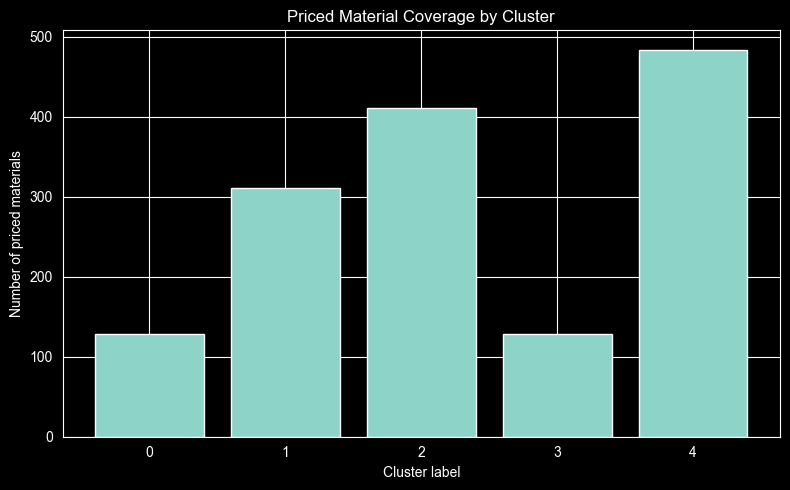

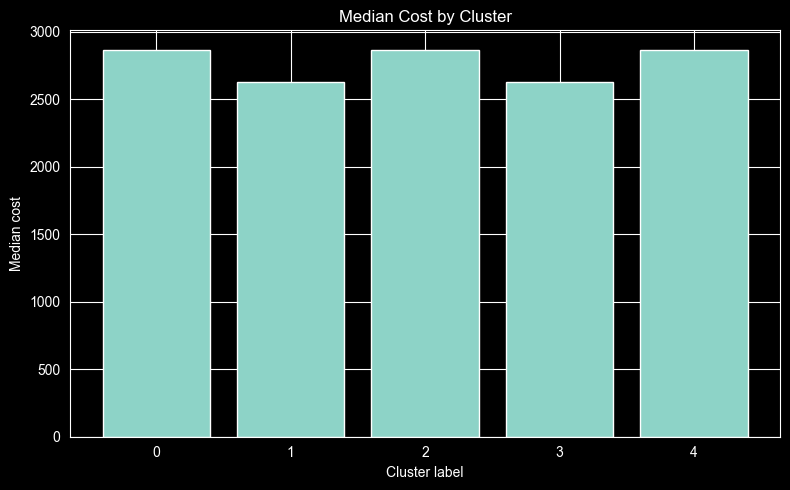

In [37]:
# Plot the result so the pattern is easier to interpret visually.
plt.figure(figsize=(8, 5))
# Convert values into analysis-friendly numeric, date, or text formats.
plt.bar(cluster_cost_summary_df["cluster_label"].astype(str), cluster_cost_summary_df["priced_material_count"])
plt.title("Priced Material Coverage by Cluster")
plt.xlabel("Cluster label")
plt.ylabel("Number of priced materials")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
# Group similar records and evaluate the quality of the cluster structure.
plt.bar(cluster_cost_summary_df["cluster_label"].astype(str), cluster_cost_summary_df["median_cost"])
plt.title("Median Cost by Cluster")
plt.xlabel("Cluster label")
plt.ylabel("Median cost")
plt.tight_layout()
plt.show()

## Save cost-grouping and alternative outputs

In [38]:
# Group similar records and evaluate the quality of the cluster structure.
cluster_cost_classes_df.to_csv(cluster_cost_classes_output, index=False)
# Save the processed output so later notebooks or report sections can reuse it.
cost_effective_alternatives_df.to_csv(cost_effective_alternatives_output, index=False)
cluster_cost_summary_df.to_csv(cluster_cost_summary_output, index=False)

print(f"Saved cluster cost classes to: {cluster_cost_classes_output}")
print(f"Saved cost-effective alternatives to: {cost_effective_alternatives_output}")
print(f"Saved supporting cluster cost summary to: {cluster_cost_summary_output}")

Saved cluster cost classes to: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\materials_pricing\materials_cluster_cost_classes.csv
Saved cost-effective alternatives to: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\materials_pricing\cost_effective_alternatives.csv
Saved supporting cluster cost summary to: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\materials_pricing\supporting\cluster_cost_summary.csv
